In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [3]:

def simulate_paths(t_0, n_intervals, T, n_sim, state_update, initial_state, noise, store_path = False):
    dt = (T - t_0) / n_intervals
    initial_state = np.asarray(initial_state, dtype=float).reshape(1, -1)
    state = np.repeat(initial_state, n_sim, axis=0)
    if store_path == False:
        for i in range(n_intervals):
            t = t_0 + i * dt
            dW = noise(dt, n_sim)
            state = state_update(state, t, dt, dW)
        return state
    else:
        path_arr = np.empty(shape = (n_intervals + 1, n_sim, state.shape[1]))
        path_arr[0, :, :] = state
        for i in range(n_intervals):
            t = t_0 + i * dt
            dW = noise(dt, n_sim)
            path_arr[i + 1, :, :] = state_update(path_arr[i, :, :].copy(), t, dt, dW)
        return path_arr
    
def european_price(t_0, n_intervals, T, n_sim, state_update, initial_state, noise, payoff, discount):
    endpoints = simulate_paths(t_0, n_intervals, T, n_sim, state_update, initial_state, noise, False)
    time_value = discount(endpoints)
    price = (time_value * payoff(endpoints)).mean()
    return price

def american_price(t_0, n_intervals, T, n_sim, state_update, initial_state, noise, payoff, discount):
    path_arr = simulate_paths(t_0, n_intervals, T, n_sim, state_update, initial_state, noise, True)
    intrinsic = payoff(path_arr)
    time_value = discount(path_arr)
    y = time_value[n_intervals]*intrinsic[n_intervals]
    for i in range(n_intervals - 1, 0, -1):
        x = path_arr[i, :,  :]
        poly = PolynomialFeatures(degree=2)
        X_poly = poly.fit_transform(x)
        model = LinearRegression()
        model.fit(X_poly, y)
        y_pred = model.predict(X_poly)
        y = np.maximum(time_value[i] * intrinsic[i], y_pred) 
    return y.mean()



In [11]:
KO = pd.read_csv("KO_stock.csv")
PEP = pd.read_csv("PEP_stock.csv")

def data_transform(stock_1, stock_2):
    #assert(stock_1["Date"] == stock_2["Date"])
    df = pd.DataFrame({"price_1":stock_1["Open"].values,
                       "price_2":stock_2["Open"].values},
                       index = pd.to_datetime(stock_1["Date"]))
    df = df.sort_index(ascending = True)
    df["log_ret_1"] = np.log(df["price_1"] / df["price_1"].shift(1))
    df["log_ret_2"] = np.log(df["price_2"] / df["price_2"].shift(1))
    return df

data = data_transform(KO, PEP)

S_0 = {"stock_1":data["price_1"].iloc[-1],
       "stock_2":data["price_2"].iloc[-1]}

endtime = data.index[-1]

def est_sigma(prices, window):
    sample = prices[-window:]
    sigma = sample.std() * np.sqrt(252)
    return sigma

def est_corr(data, window):
    sample_1 = data["price_1"][-window:]
    sample_2 = data["price_2"][-window:]
    return sample_1.corr(sample_2)

t_0 = 0
n_intervals = 1000
T = 0.25
n_days = round(365*T)
n_sim = 5000

window = 30

initial_state = np.array([1, 1, 0])

p = est_corr(data, window)
sigma_1 = est_sigma(data["log_ret_1"], window)
sigma_2 = est_sigma(data["log_ret_2"], window)
r = 0.01


def noise(dt, n_sim):
    dW1 = np.random.normal(0, np.sqrt(dt), n_sim)
    dW2 = np.random.normal(0, np.sqrt(dt), n_sim)
    dW3 = p * dW1 + np.sqrt(1 - p ** 2) * dW2
    return np.array((dW1, dW3)).T

def state_update(state, t, dt, dW):
    new_state = np.empty_like(state)
    new_state[:, 0] = state[:, 0] + r * state[:, 0] * dt + sigma_1 * state[:, 0] * dW[:, 0]
    new_state[:, 1] = state[:, 1] + r * state[:, 1] * dt + sigma_2 * state[:, 1] * dW[:, 1]
    new_state[:, 2] = state[:, 2] + abs(state[:, 0] - state[:, 1]) * dt
    return new_state

def amer_payoff(paths):
     return paths[:, :, 2]

def amer_discount(path_arr):
    times = np.linspace(t_0, T, n_intervals + 1)
    dis_vec = np.exp(-r * times).reshape(1,-1)
    dis_arr = np.repeat(dis_vec, n_sim, axis = 0).T
    dis_arr[0, :] = 0
    return dis_arr

def euro_discount(endpoints):
    return np.exp(-r*(T - t_0))

def euro_payoff(endpoints):
    return endpoints[:, 2]

print(american_price(t_0, n_intervals, T, n_sim, state_update, initial_state, noise, amer_payoff, amer_discount))
print(european_price(t_0, n_intervals, T, n_sim, state_update, initial_state, noise, euro_payoff, euro_discount))

0.006055405699208168
0.005978416506343751


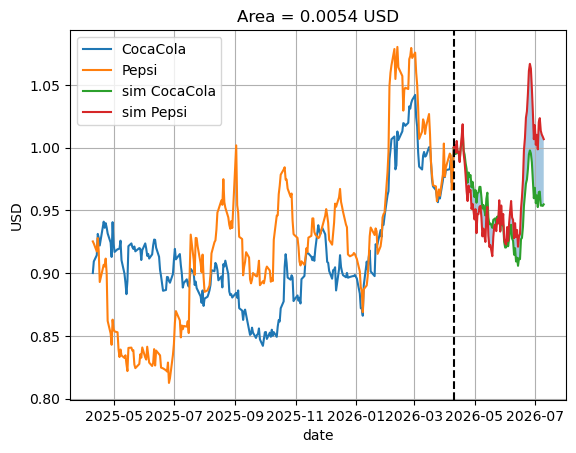

In [12]:
alpha_1 = 0.1
alpha_2 = 0.2

n_intervals = n_days

def state_update(state, t, dt, dW):
    new_state = np.empty_like(state)
    new_state[:, 0] = state[:, 0] + alpha_1 * state[:, 0] * dt + sigma_1 * state[:, 0] * dW[:, 0]
    new_state[:, 1] = state[:, 1] + alpha_2 * state[:, 1] * dt + sigma_2 * state[:, 1] * dW[:, 1]
    new_state[:, 2] = state[:, 2] + abs(state[:, 0] - state[:, 1]) * dt
    return new_state

result = simulate_paths(t_0, n_intervals, T, n_sim, state_update, initial_state, noise, store_path = True)
S1 = result[:, 0, 0]
S2 = result[:, 0, 1]
area = result[n_intervals, 0, 2]

future_df = pd.DataFrame(data = {"S1":S1, "S2":S2}, index = pd.date_range(start=endtime, periods = n_days + 1, freq="D"))


plt.plot(data.index, data["price_1"]/S_0["stock_1"], label = "CocaCola")
plt.plot(data.index, data["price_2"]/S_0["stock_2"], label = "Pepsi")
plt.plot(future_df.index, future_df["S1"], label = "sim CocaCola")
plt.plot(future_df.index, future_df["S2"], label = "sim Pepsi")
plt.fill_between(future_df.index, future_df["S1"], future_df["S2"], alpha = 0.4)
plt.axvline([endtime], linestyle = "--", color = "black")
plt.grid(which = "major")
plt.xlabel("date")
plt.ylabel("USD")
plt.title(f"Area = {round(area, 5)} USD")
plt.legend()